In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing.preprocessing import load_data, clean_data, prepare_features, split_data

In [4]:
df = load_data("../data/raw/amazon_sales_dataset.csv")
df = clean_data(df)

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [5]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(5), object(3)
memory usage: 5.0+ MB


Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

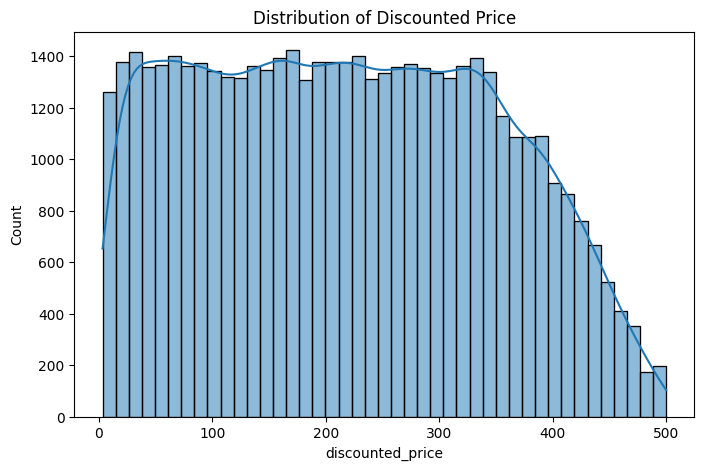

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["discounted_price"], kde=True)
plt.title("Distribution of Discounted Price")
plt.show()

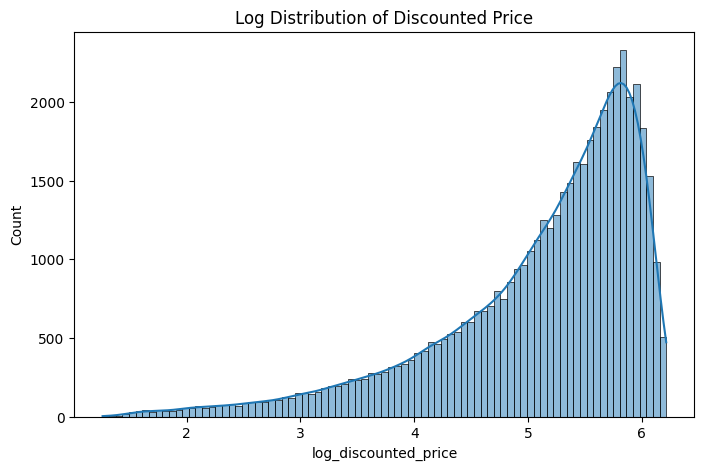

In [8]:
df = df[df["discounted_price"] > 0].copy()
df["log_discounted_price"] = np.log(df["discounted_price"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_discounted_price"], kde=True)
plt.title("Log Distribution of Discounted Price")
plt.show()

In [9]:
X, y = prepare_features(df, target="discounted_price")

X.head()

,price,discount_percent,quantity_sold,rating,review_count,product_category,customer_region,payment_method,order_month,order_dayofweek
0,128.75,10,4,3.5,443,Books,North America,UPI,4,2
1,302.60,20,5,3.7,475,Fashion,Asia,Credit Card,3,6
2,495.80,20,2,4.4,183,Sports,Europe,UPI,9,2
3,371.95,15,4,5.0,212,Books,Middle East,UPI,4,6
4,201.68,0,4,4.6,308,Beauty,Middle East,UPI,3,6


In [10]:
X_train, X_test, y_train, y_test = split_data(X, y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (40000, 10)
Test size: (10000, 10)


In [11]:
(df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2)

order_id                0.0
order_date              0.0
product_id              0.0
product_category        0.0
price                   0.0
discount_percent        0.0
quantity_sold           0.0
customer_region         0.0
payment_method          0.0
rating                  0.0
review_count            0.0
discounted_price        0.0
total_revenue           0.0
log_discounted_price    0.0
dtype: float64

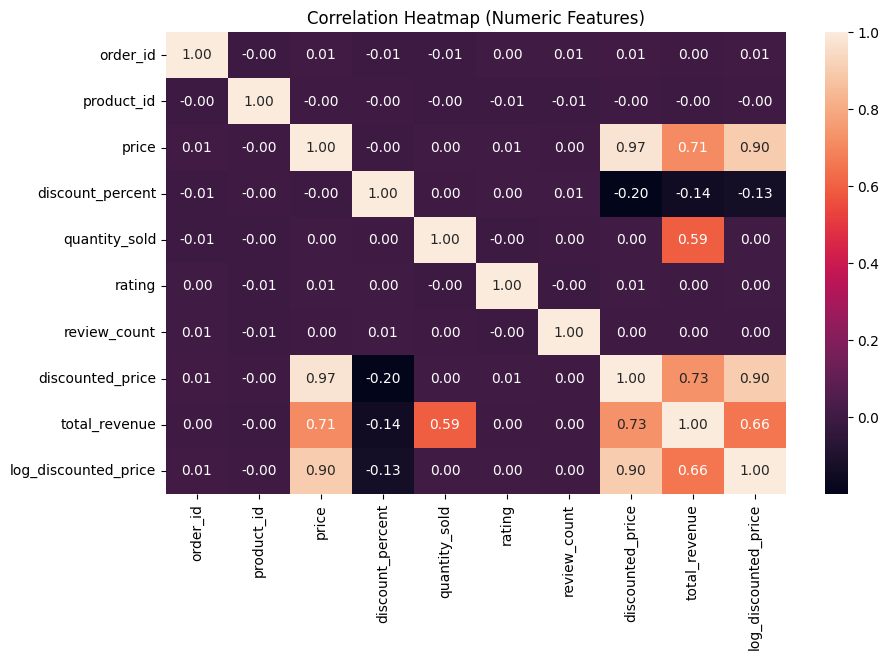

In [12]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()